# Lissajous Figures and Quality Assurance

The provided dataset contains quality control records from PrecisionS&C, a company manufacturing two primary product lines:

- Power supplies capable of generating alternating current (AC) at precisely defined, constant frequencies up to a maximum of 100 Hz.
- Inductor coils with nominal inductances of 6 H, 3 H, 2 H, 1.5 H, 1.2 H, and 1 H.

To ensure only compliant equipment is delivered to customers, randomly selected power supplies are subjected to quality control testing prior to shipment. The testing protocol is as follows: a reference power supply calibrated to deliver AC current at exactly 100 Hz is connected to an oscilloscope in parallel with the unit under evaluation. The phase relationship between the two signals is adjusted until a closed Lissajous figure is observed. A power supply is classified as faulty if it cannot be paired with any single inductor coil manufactured by PrecisionS-C to achieve a total inductor impedance of magnitude 377 ohm rounded to three significant figures — i.e. the computed value must fall in the range [376.50; 377.5) ohm. Any tested unit identified as faulty must be documented in the quality assurance form. Units which were not tested do not have a measurement ID and are assumed not to be faulty.

The dataset is provided as a .zip archive containing a table summarizing all measurements conducted during the specified time period, Lissajous figure images with filenames matched to measurement IDs in the table, and a quality assurance form template.

Produce the following outputs:

1. A PDF version of the completed quality assurance form, containing one entry for each faulty power supply.
2. A professionally formatted PNG file displaying the histogram of daily faulty units.
3. A TXT file listing all production machines with a failure rate exceeding 10%, based on the presented randomly sampled measurements.
________________________________________________________

Import necessary dependencies used in the data generation and data processing pipeline.

In [1]:
import numpy as np
import random
import pandas as pd
import string
import matplotlib.pyplot as plt
import os
import shutil

This is where you can set all the parameters of the simulation and data generation.

- **NUMBER_OF_UNITS** : Number of items in the spreadsheet
- **NUMBER_OF_DAYS** : Period over which we want to produce the data
- **NUMBER_OF_MEASUREMENTS** : Number of performed measurements -> corresponds more or less to the number of generated oscilloscope images, since the generation of the image is also probabilistically determined. Image is generated with the probability NUMBER_OF_MEASUREMENTS/NUMBER_OF_UNITS.
- **MACHINE_FAILURE** : Dictionary with specifiable machine labels and their failure rate (probability that the machine will be faulty).
- **BATCHES:** : Labeling of production batches
- **FREQUENCY_PHASESHIFT** : This parameter is tuned by hand, just to make sure that we are producing Lissajous figures that are clearly readable (no overlapping lines, clearly closed figure,...)

In [2]:
# Set paths and create clean folders for spectra
path = "./"
os.chdir(path)
folder = path + 'input_data/oscilloscope_output'
shutil.rmtree(folder)
os.makedirs(folder)

SEED = np.random.randint(0, 1000000) # Use a random seed for each run
# SEED = 42 # Use this to make the generation reproducible
random.seed(SEED)


NUMBER_OF_UNITS = 100
NUMBER_OF_DAYS = 30
NUMBER_OF_MEASUREMENTS = 10
MACHINES_FAILURE = {"BNPQF53": 0.9,
                    "SPN98i" : 0.4,
                    "RSTv3" : 0.01,
                    "720i" : 0.80,
                    "3434tt" : 1.0,
                    "98u" : 0.05
                    }
BATCHES = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L" ]
FREQUENCY_PHASESHIFT = {"10": np.pi,
                        "20": np.pi/4,
                        "30": np.pi/4,
                        "40": np.pi/3,
                        "50": np.pi/3,
                        "60": np.pi/4,
                        "70": np.pi/3,
                        "80": np.pi/3,
                        "90": np.pi/3,
                        "100":np.pi/2
                        }

Data generation pipeline.

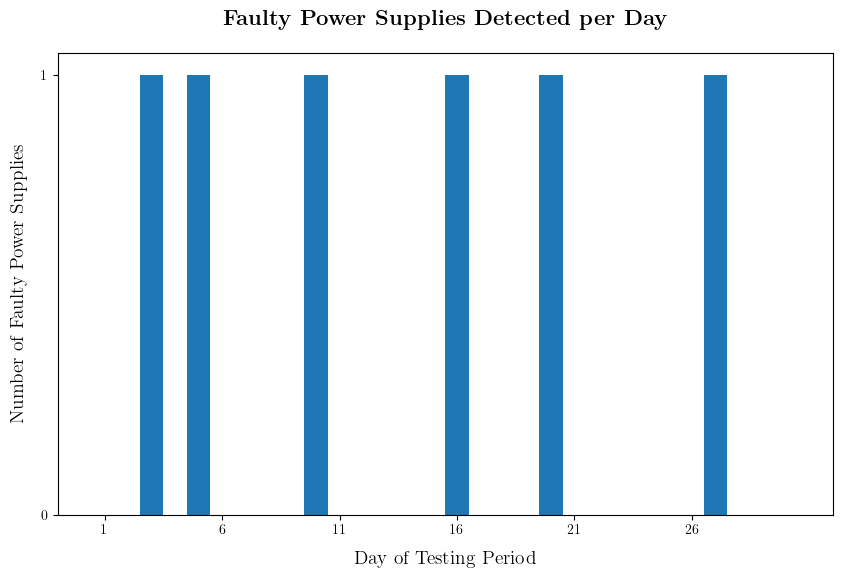

   machine  failures  total  failure_rate
0   3434tt         3      3           1.0
3  BNPQF53         2      2           1.0
5   SPN98i         1      2           0.5


In [3]:
############################################################
################ Dataframe format
############################################################

df = pd.DataFrame({'day' : pd.Series(dtype='int'),
                    'machine' : pd.Series(dtype='str'),
                    'supply_ID' : pd.Series(dtype='str'),
                    'failure' : pd.Series(dtype='int'),
                    'batch' : pd.Series(dtype='str'),
                    'frequency' : pd.Series(dtype='int'),
                    'reference_frequency' : pd.Series(dtype='int'),
                    'phase_shift' :pd.Series(dtype='float'),
                    'a1' :pd.Series(dtype='int'),
                    'a2' : pd.Series(dtype='int'),
                    'measurement_id' : pd.Series(dtype='str')})


############################################################
################ Loop to generate data files
############################################################

for measurement in range(NUMBER_OF_UNITS):
    day = random.randint(1, NUMBER_OF_DAYS)
    reference_frequency = 100
    machine = random.choice(list(MACHINES_FAILURE.keys()))
    failure = (random.uniform(0,1) < MACHINES_FAILURE[machine])
    measured = (random.uniform(0,1) < NUMBER_OF_MEASUREMENTS/NUMBER_OF_UNITS)
    batch = random.choice(BATCHES)
    supply_id = ''.join(random.choices(string.digits, k=8))

    #TODO Check this, but it should be that all frequencies above 60 Hz should be faulty
    if failure:
        valid_keys = [k for k in FREQUENCY_PHASESHIFT.keys() if int(k) > 61]
        frequency = int(random.choice(valid_keys))
    else:
        valid_keys = [k for k in FREQUENCY_PHASESHIFT.keys() if int(k) < 61]
        frequency = int(random.choice(valid_keys))
    phase_shift = FREQUENCY_PHASESHIFT[str(frequency)]
    a1 = random.uniform(3, 5)
    a2 = random.uniform(3, 5)
    if measured:
        measurement_id = ''.join(random.choices(string.ascii_letters + string.digits, k=9))
        # Time array
        t = np.linspace(0, 2 * np.pi, 10000)

        # Parametric equations
        x = a1 * np.sin(reference_frequency * t + phase_shift)
        y = a2 * np.sin(frequency * t)

        # Plot
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.set_facecolor("black")
        fig.patch.set_facecolor("black")
        ax.plot(x, y, color="turquoise")
        ax.set_xticks(np.linspace(-6, 6, 9))
        ax.set_yticks(np.linspace(-6, 6, 9))
        ax.grid(True, color="white", linewidth=0.5)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        plt.tight_layout()
        plt.savefig(f"{path}/input_data/oscilloscope_output/ID_{measurement_id}.png")
        plt.close()
    else:
        measurement_id = ""

    # Fill the dataframe with the generated data
    new_row = pd.DataFrame([{'day' : day,
                             'supply_ID' : supply_id,
                             'machine' : machine,
                             'failure' : failure,
                             'measured' : measured,
                             'batch' : batch,
                             'frequency' : frequency,
                             'reference_frequency' : reference_frequency,
                             'phase_shift' : phase_shift,
                             'a1' : a1,
                             'a2' : a2,
                             'measurement_id' : measurement_id}])
    df = pd.concat([df, new_row], ignore_index=True)

# Print the dataframe to a .csv file, only with the columns that are needed for the analysis, and sorted by day
df.sort_values("day")[['day', 'supply_ID', 'machine', 'batch', 'measurement_id']].to_csv("input_data/measurements.csv", index=False)

############################################################
################ Produce histogram for QA
############################################################

# LATeX fonts
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

plt.figure(figsize=(10, 6))
plt.yticks(np.arange(0, 4, 1))
df_filtered = df[df['measured'] == 1]
bins = np.arange(0.5, NUMBER_OF_DAYS + 1.5, 1)
plt.hist(df_filtered['day'], bins=bins, weights=df_filtered['failure'])
plt.xticks(np.arange(1, NUMBER_OF_DAYS + 1, 5))
plt.xlabel('Day of Testing Period', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Number of Faulty Power Supplies', fontsize=14, fontweight='bold', labelpad=10)
plt.title('\\textbf{Faulty Power Supplies Detected per Day}',
             fontsize=16, fontweight='bold', pad=20)
plt.grid(False)
plt.savefig(f'./ground_truth/histogram.png')
plt.show()


############################################################
###### Create the table with data that needs to be filled 
###### in the .pdf file
############################################################

failure_rate = df[df["measured"] == 1].groupby('machine').agg(
    failures=('failure', 'sum'),
    total=('failure', 'count')
).reset_index()

filtered_rows = df[(df["measured"] == 1) & (df["frequency"] > 60)]
filtered_rows[["supply_ID", "machine" ,"batch", "frequency"]].to_csv("./ground_truth/table_for_QA.csv", index=False)

failure_rate['failure_rate'] = failure_rate['failures'] / failure_rate['total']
# Filter machines with failure rate > 10%
high_failure = failure_rate[failure_rate['failure_rate'] > 0.1]
high_failure[['machine']].to_csv('./ground_truth/faulty_machines_over_10percent.txt', index=False, header=False)
print(high_failure)

Save the dataframe with intermediate results for future inspection and display data plotted in the graph.

In [4]:
# Save dataframe for potential further analysis
df.to_pickle("./ground_truth/dataframe.pkl")